<a href="https://colab.research.google.com/github/Carmen10-171/07MIAR_Redes-Neuronales/blob/main/Actividad_C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACTIVIDAD C1-Deep Learning y Deep vision
## MODEL_NAME = "distilgpt2"

#### **- Cargando el conjunto de datos**

In [ ]:
# Instalación de librerías

import torch
import transformers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import transformers
import torch

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)

print("AutoModelForCausalLM" in dir(transformers))
print("AutoTokenizer" in dir(transformers))


Transformers: 5.18.0
Torch: 2.12.0+cpu
True
True


In [ ]:

#!{sys.executable} -m pip uninstall -y transformers
!{sys.executable} -m pip install --no-cache-dir transformers==4.45.2


print("Version:", transformers.__version__)
print("Archivo:", transformers.__file__)

Version: 5.18.0
Archivo: C:\Users\ccope\miniconda3\Lib\site-packages\transformers\__init__.py


In [ ]:
import os

ruta = r"C:\Users\ccope\miniconda3\Lib\site-packages\transformers"

print(os.path.exists(ruta))

for archivo in os.listdir(ruta)[:20]:
    print(archivo)

True
activations.py
activations_tf.py
agents
audio_utils.py
benchmark
cache_utils.py
commands
configuration_utils.py
convert_graph_to_onnx.py
convert_pytorch_checkpoint_to_tf2.py
convert_slow_tokenizer.py
convert_slow_tokenizers_checkpoints_to_fast.py
convert_tf_hub_seq_to_seq_bert_to_pytorch.py
data
debug_utils.py
deepspeed.py
dependency_versions_check.py
dependency_versions_table.py
dynamic_module_utils.py
feature_extraction_sequence_utils.py


In [ ]:
import sys

print(sys.executable)

# Instalar versiones compatibles
#!{sys.executable} -m pip uninstall -y transformers tokenizers
!{sys.executable} -m pip install --no-cache-dir transformers==4.45.2
!{sys.executable} -m pip install --no-cache-dir tokenizers==0.20.3
!{sys.executable} -m pip install sentencepiece
import transformers
import torch

print("Version:", transformers.__version__)
print("Archivo:", transformers.__file__)
print("Torch:", torch.__version__)
from transformers.models.gpt2.tokenization_gpt2 import GPT2Tokenizer

print("GPT2Tokenizer OK")


import transformers
import pkg_resources

for pkg in ["transformers", "accelerate", "peft", "trl", "optimum"]:
    try:
        print(pkg, pkg_resources.get_distribution(pkg).version)
    except:
        print(pkg, "NO INSTALADO")


import torch

print(torch.__version__)
import torch.nn as nn

encoder_layer = nn.TransformerEncoderLayer(
    d_model=64,
    nhead=4,
    batch_first=True
)

print(encoder_layer)
print(model)


C:\Users\ccope\miniconda3\python.exe
Version: 5.18.0
Archivo: C:\Users\ccope\miniconda3\Lib\site-packages\transformers\__init__.py
Torch: 2.12.0+cpu
GPT2Tokenizer OK
transformers 4.45.2
accelerate NO INSTALADO
peft NO INSTALADO
trl NO INSTALADO
optimum NO INSTALADO
2.12.0+cpu
TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear1): Linear(in_features=64, out_features=2048, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=2048, out_features=64, bias=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)
MiniTransformer(
  (embedding): Embedding(1000, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLa

#### **- Celda 3: Modelo Transformer sencillo**

In [ ]:
import torch
import torch.nn as nn

class MiniTransformer(nn.Module):

    def __init__(
        self,
        vocab_size=1000,
        d_model=64,
        nhead=4,
        num_layers=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.transformer(x)

        logits = self.fc(x)

        return logits


model = MiniTransformer()

print(model)



MiniTransformer(
  (embedding): Embedding(1000, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1000, bias=True)
)


#### **- Celda 4: Model Summary**

In [ ]:
print(model)

MiniTransformer(
  (embedding): Embedding(1000, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1000, bias=True)
)


#### **- Celda 5: Número de parámetros**

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parámetros: {total_params:,}"
)

Parámetros: 691,304


#### **- Celda 6: Ejemplo de entrada**

In [ ]:
input_ids = torch.tensor(
    [[10,42,77,15,99]]
)

print(input_ids)
print(input_ids.shape)

tensor([[10, 42, 77, 15, 99]])
torch.Size([1, 5])


Salida aproximada:

In [ ]:
torch.Size([1,5])

torch.Size([1, 5])

#### **- Celda 7: Distribución del tensor de entrada**


In [ ]:
input_ids = torch.tensor(
    [[10,42,77,15,99]]
)

print(input_ids)
print(input_ids.shape)

tensor([[10, 42, 77, 15, 99]])
torch.Size([1, 5])


#### **- Celda 8: Obtener logits**

In [ ]:
with torch.no_grad():

    logits = model(input_ids)

print(logits.shape)

torch.Size([1, 5, 1000])


Salida aproximada:

In [ ]:
torch.Size([1, 5, 50257])

torch.Size([1, 5, 50257])

#### **- Celda 9: Distribución de logits**

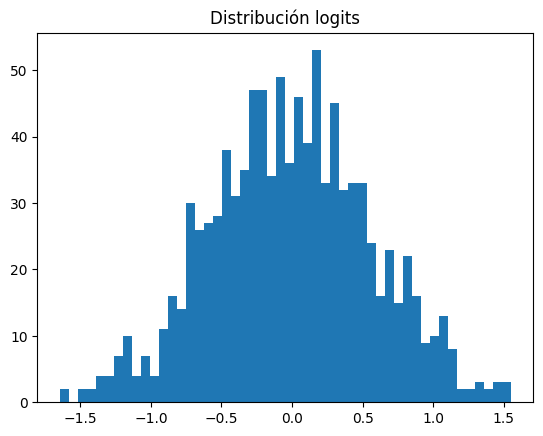

In [ ]:
import matplotlib.pyplot as plt

last_logits = logits[0,-1].numpy()

plt.hist(
    last_logits,
    bins=50
)

plt.title("Distribución logits")
plt.show()

#### **- Celda 10: Predicción siguiente token**

In [ ]:
attention = nn.MultiheadAttention(
    embed_dim=64,
    num_heads=4,
    batch_first=True
)

#### **- Celda 11: Obtener Self-Attention**

In [ ]:
emb = model.embedding(input_ids)

out, weights = attention(
    emb,
    emb,
    emb,
    need_weights=True
)
print(weights.shape)

torch.Size([1, 5, 5])


#### **- Celda 12: Mapa de calor de atención**

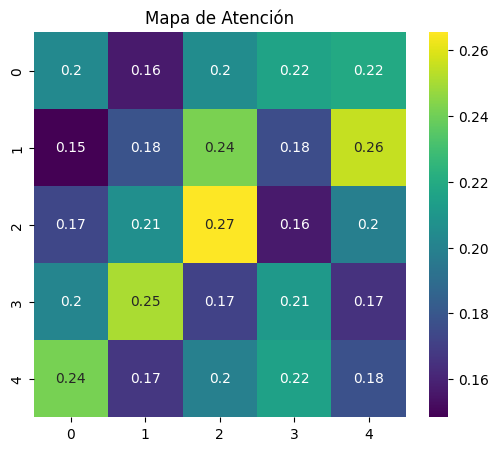

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    weights[0].detach().numpy(),
    cmap="viridis",
    annot=True
)

plt.title("Mapa de Atención")
plt.show()

#### **- Celda 13: Segundo ejemplo**

In [ ]:
input_ids2 = torch.tensor(
    [[5,12,88,300,45,71]]
)

emb2 = model.embedding(input_ids2)

_, weights2 = attention(
    emb2,
    emb2,
    emb2,
    need_weights=True
)

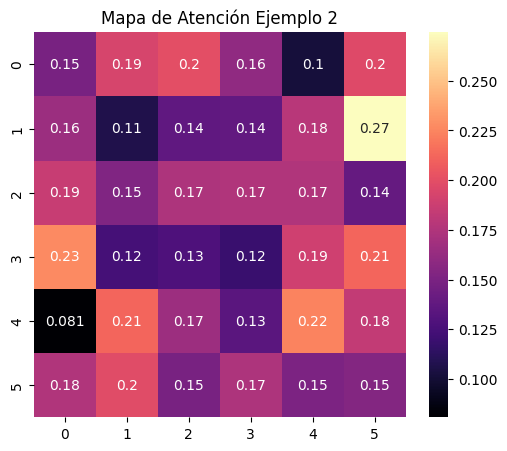

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    weights2[0].detach().numpy(),
    cmap="magma",
    annot=True
)

plt.title("Mapa de Atención Ejemplo 2")
plt.show()